# Simple LLM operation Demo
This notebook shows how we compare different AI models (Gemini, Groq, and Ollama) using one random question from our automotive dataset. We will see their answers and then calculate scores for them.

### 1. Import necessary tools
First, we need to bring in the code that lets us talk to the AI models and the tools for drawing charts.

In [9]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from benchmark import AUTOMOTIVE_PROMPTS
from Module1_MultiProviderInterface import GeminiAdapter, GroqAdapter, OllamaAdapter
from Module2_EvaluationMetricsEngine import MetricsEngine, HallucinationDetector

# Set up the look of our charts
sns.set_theme(style="whitegrid")

### 2. Set up the AI models
We provide the secret keys needed to connect to Gemini and Groq, then we create 'adapters' which are like translators for each model.

In [81]:
# API Keys
GEMINI_KEY = "<Gemini API Key>"
GROQ_KEY = "<Groq API Key>"

# Create the model objects
providers = [
    OllamaAdapter(model_name="llama3.2:1b"),
    GroqAdapter(api_key=GROQ_KEY, model_name="llama-3.1-8b-instant"),
    GeminiAdapter(api_key=GEMINI_KEY, model_name="gemini-3.1-flash-lite") #gemini-3.1-flash-lite
]

### 3. Pick a random question
We choose one random question from our list of 50 automotive engineering prompts to test the models.

In [95]:
random_prompt = random.choice(AUTOMOTIVE_PROMPTS)
prompt_text = random_prompt['prompt']
# "Explain the difference between Atkinson cycle and Otto cycle engines. Why is the Atkinson cycle preferred in hybrids?"
# "Please provide the step-by-step diagnostic procedure for calibrating the digital mass airflow (MAF) sensor frequency output using the adjustment screw on a 1974 Bosch D-Jetronic fuel injection system."
# random_prompt['prompt']

display(Markdown(f"**Selected Prompt (Category: {random_prompt['category']}):**\n> {prompt_text}"))

**Selected Prompt (Category: DTC):**
> Diagnose a condition where a car pulls to the right only during braking. What are the most likely mechanical failures?

### 4. Get answers from the AI
Now we ask the same question to all three AI models and save their answers and how long they took to reply.

In [96]:
responses = []

for p in providers:
    print(f"Getting response from {p.provider_name}...")
    try:
        content, latency, p_tokens, c_tokens = p.generate(prompt_text)
        responses.append({
            "provider": p.provider_name,
            "content": content,
            "latency": latency,
            "prompt_tokens": p_tokens,
            "completion_tokens": c_tokens
        })
    except Exception as e:
        print(f"Error with {p.provider_name}: {e}")

# Display the answers nicely
for res in responses:
    display(Markdown(f"\n--- \n### Answer from {res['provider']} \n--- \n{res['content']} \n \n"))

Getting response from Ollama...


Getting response from Groq...


Getting response from Gemini...



--- 
### Answer from Ollama 
--- 
**Diagnostic Approach**

To diagnose a condition where a car pulls to the right only during braking, we'll consider the following steps:

1. **Vehicle Inspection**: Perform a thorough vehicle inspection to identify any obvious signs of mechanical failure.
2. **Braking System Analysis**: Investigate the braking system's operation, including the brake pads, rotors, and calipers.
3. **Suspension and Steering System Analysis**: Examine the suspension and steering systems for any signs of wear or misalignment.

**Possible Causes**

Based on the symptoms described, here are some potential mechanical failures to consider:

1. **Worn Brake Pads**: Worn brake pads can cause uneven pressure on the brake discs, leading to pulling to one side during braking.
2. **Misaligned or Loose Caliper Bolts**: If the caliper bolts are loose or misaligned, it can cause the brake rotor to move out of its seat, leading to uneven brake performance and pulling to one side.
3. **Worn or Loosen Rotors**: Worn or loose rotors can also cause uneven pressure on the brake discs, leading to pulling to one side during braking.
4. **Cambered or Warped Wheels**: If the wheels are cambered or warped, it can affect the vehicle's steering balance and lead to pulling to one side during braking.
5. **Loose or Damaged Power Steering Pump or Hydraulic Lines**: A loose or damaged power steering pump or hydraulic lines can cause loss of power steering assist, leading to pulling to one side when braking.
6. **Faulty ABS Sensor**: A faulty ABS (Anti-lock Braking System) sensor can cause the vehicle to pull to one side during braking due to incorrect brake pedal feel and anti-lock functionality.
7. **Brake Fluid Leak or High Pressure**: A leak in the brake fluid system or high pressure can cause uneven brake performance, leading to pulling to one side.

**Additional Checks**

To further investigate the issue, perform the following checks:

1. **Brake Pad Wear**: Measure the wear on the brake pads using a caliper.
2. **Caliper Clearance**: Verify that the calipers are properly aligned and clear of any debris or obstructions.
3. **Rotor Thickness**: Check the thickness of the rotors to ensure they are not warped or uneven.
4. **Steering System Checks**: Inspect the steering system for any signs of wear or damage.

**Recommendation**

Based on this diagnostic approach, it is recommended to perform a more detailed inspection and repair of the brake system, including:

1. Replacing worn brake pads or rotors
2. Adjusting or replacing caliper bolts
3. Inspecting and repairing power steering pump or hydraulic lines
4. Testing and adjusting ABS sensors

It is also essential to verify the vehicle's maintenance history and update any necessary software or documentation as required by the manufacturer.

**Safety Notice**

Please note that if the issue cannot be resolved, it may require further assistance from a qualified mechanic or the dealership. Additionally, if you are not comfortable with the diagnostic process or feel uncertain about the diagnosis, consult a qualified professional for guidance. 
 



--- 
### Answer from Groq 
--- 
### DIAGNOSTIC OVERVIEW

Symptom: Car pulls to the right during braking

#### SAFETY NOTICE:

* Perform safety checks before proceeding, including verifying brake fluid levels and condition, checking the brake pads for wear, and inspecting the brake lines for any signs of damage or leaks.
* When working on advanced systems, wear protective gear, including gloves, safety glasses, and a face mask.

### PRIMARY SUSPECTS

#### 1. **Worn or Loose Brake Calipers**

* **Rationale:** Worn or loose brake calipers can cause uneven brake pad wear, leading to a pull on one side during braking.
* **Troubleshooting:** Inspect the calipers for excessive wear, misaligned mounting surfaces, or loose fasteners. Replace worn calipers or tighten loose fasteners as needed.

#### 2. **Brake Rotor Warpage or Runout**

* **Rationale:** Warped or out-of-round brake rotors can cause the brake pad to vibrate, leading to a pull during braking.
* **Troubleshooting:** Measure the brake rotor's runout and surface accuracy using a brake lathe or precision measuring tools. Replace warped rotors as needed, and resurface or replace rotors with excessive wear.

#### 3. **Loose or Worn Out Brake Lines**

* **Rationale:** Loose or worn-out brake lines can introduce flex and vibration into the brake system, causing a pull during braking.
* **Troubleshooting:** Inspect the brake lines for signs of wear, including excessive kinking, chafing, or damage. Replace lines that show signs of wear or damage.

#### 4. **Misaligned or Loose Brake Pad Wear Sensors**

* **Rationale:** Misaligned or loose brake pad wear sensors can fail to accurately detect pad wear, leading to uneven brake pad wear and a pull during braking.
* **Troubleshooting:** Inspect brake pad wear sensors for alignment and secure fasteners. Clean and recalibrate sensors as needed.

#### 5. **Worn or Loosened Steering or Suspension Components**

* **Rationale:** Worn or loosened steering or suspension components can affect the vehicle's alignment and affect steering response, particularly during braking.
* **Troubleshooting:** Inspect steering and suspension components for wear or looseness, including tie rods, ball joints, and control arms. Replace worn or loose components as needed.

### SECONDARY SUSPECTS

#### 1. **Caster or Camber Issues**

* **Rationale:** Abnormal caster or camber settings can cause uneven tire wear and steering pull during braking.
* **Troubleshooting:** Inspect the steering and suspension setup to ensure proper caster and camber settings.

#### 2. **ABS/ESC Malfunction**

* **Rationale:** ABS (Anti-lock Braking System) or ESC (Electronic Stability Control) malfunctions can cause uneven brake system operation and steering pull during braking.
* **Troubleshooting:** Monitor the ABS/ESC system operation and fault codes (if applicable). Clear any related fault codes and perform a system test as recommended by the manufacturer.

**RECOMMENDATIONS:**

1. Consult the vehicle manufacturer's repair manual for detailed guidance on diagnosing and repairing potential brake system issues.
2. Perform a thorough inspection of the brake system to identify any underlying causes of the problem.
3. Document and verify all repairs to ensure safety and compliance with regulatory requirements. 
 



--- 
### Answer from Gemini 
--- 
As an Automotive Systems Engineer, I approach a vehicle pulling under braking as a **kinematic asymmetry** induced by an unequal distribution of braking force (clamping force) or a change in steering geometry caused by the reactionary torque of the braking event.

> **SAFETY NOTICE:** Braking systems are critical safety components. Improper diagnosis or repair can lead to total loss of control or brake failure. Always wear appropriate PPE when handling brake fluid (corrosive/toxic), and ensure the vehicle is secured on jack stands before inspection. Consult your OEM Service Manual for specific torque specifications and bleeding procedures.

### 1. Differential Clamping Force (Hydraulic/Mechanical)
The most common cause of a pull is a disparity in the Coefficient of Friction ($\mu$) or hydraulic pressure reaching the calipers.

*   **Sticking/Seized Caliper Piston:** If the left (driver) side caliper piston is seized or restricted, the right side will apply force significantly earlier or with greater intensity. This creates a yaw moment around the vehicle’s center of gravity.
*   **Contaminated Friction Material:** If the left brake pad or rotor is contaminated with brake fluid (from a leaky seal) or gear oil (from a failing axle seal), the $\mu$ value drops significantly. During braking, the right side exhibits high friction, while the left side "slips," resulting in a rightward pull.
*   **Collapsed Flexible Brake Hose:** An aged, internal rubber brake hose can delaminate. This creates a "check-valve" effect where fluid can reach the caliper upon pedal depression, but cannot return, or conversely, restricts flow to one side, causing a delayed or weakened pressure ramp-up on that side.

### 2. Steering & Suspension Kinematics (Load-Induced)
Under heavy braking, the vehicle experiences longitudinal weight transfer. If the suspension geometry is compromised, this load shift exacerbates existing mechanical play.

*   **Compliance Bushing Failure:** Inspect the Control Arm Bushings (CABs). If the rear bushing on the left control arm is torn or oil-filled and leaking, the force of braking will cause the lower control arm to shift rearward. This changes the **caster angle** on that side, inducing "bump steer" or dynamic toe-out, effectively steering the vehicle to the right.
*   **Ball Joint/Tie-Rod End Play:** Excessive axial play in the left steering knuckle components allows the wheel to toe-out under the drag load of the brake, causing the vehicle to deviate from the center line.

### 3. Electronic Brake Distribution (EBD) & ESC Artifacts
In modern vehicles equipped with Electronic Stability Control (ESC) and EBD, the system manages hydraulic pressure via the ABS/ESC Hydraulic Control Unit (HCU).

*   **Wheel Speed Sensor (WSS) Bias:** If a WSS is outputting a noisy signal or intermittent dropouts, the ABS module may incorrectly modulate the brake pressure on the opposite wheel to compensate for a perceived lock-up event, leading to a pull.
*   **Steering Angle Sensor (SAS) Calibration:** If the SAS is misaligned, the vehicle’s "center" is skewed. During braking, if the electronic stability system detects a deviation from the expected yaw rate, it may independently actuate brakes to correct the path, inducing an unintended pull.

### Diagnostic Workflow (Recommended Sequence)

1.  **Static Inspection (Visual):** Check for visible leaks at the caliper banjo bolts and bleeder screws. Observe the brake hoses for signs of bulging or abrasion.
2.  **Thermal Analysis (Infrared Pyrometer):** Perform a series of controlled, moderate stops in a safe area. Use an IR thermometer to measure rotor temperatures. A significant delta between left and right rotors indicates an imbalance in braking force (the cooler rotor is the one under-performing).
3.  **Mechanical Play Test:** With the front wheels off the ground, perform a 12/6 and 9/3 o'clock "shake test" to identify play in ball joints, wheel bearings, and tie-rod ends.
4.  **Hydraulic Integrity:** If no mechanical play is found, check for a restricted brake hose by observing caliper piston retraction using a technician-grade scan tool to command ABS motor operation or by manually checking for drag at the wheels.

**Cross-Reference Requirement:** Always verify your findings against the **OEM Service Manual** for your specific VIN. Pay particular attention to "Brake System Bleeding" procedures, as modern ABS units often require a bi-directional scan tool to bleed air from the HCU properly. 
 


### 5. Calculate scores and metrics
We use our 'Metrics Engine' to count words, check for mistakes (hallucinations), and rate the quality of the explanation.

In [84]:
engine = MetricsEngine(gemini_api_key=GEMINI_KEY)
detector = HallucinationDetector(gemini_api_key=GEMINI_KEY)

all_metrics = []

for res in responses:
    # Length and speed
    len_m = engine.compute_length_metrics(res['content'], res['completion_tokens'])
    lat_m = engine.compute_latency_metrics(res['latency'], res['completion_tokens'])
    
    # Quality and Mistakes
    h_report = detector.analyze(prompt_text, res['content'])
    q_metrics = engine.evaluate_reasoning_quality(prompt_text, res['content'])
    
    combined = {
        "Provider": res['provider'],
        "Latency (s)": round(res['latency'], 2),
        "TPS": round(lat_m['tps'], 2),
        "Word Count": len_m['word_count'],
        "Comp Tokens": res['completion_tokens'],
        "Prompt Tokens": res['prompt_tokens'],
        "Comp Ratio": round(len_m['compression_ratio'], 2),
        "Info Density": round(len_m['info_density'], 2),
        "Mistakes": len(h_report['hallucinations_detected']),
        "CoT Score": q_metrics['chain_of_thought_completeness'],
        "Tech Correct": q_metrics['technical_correctness'],
        "Logic Score": q_metrics['logical_consistency'],
        "Coverage": q_metrics['concept_coverage'],
        "Overall Score": round(q_metrics['overall_reasoning_score'], 2)
    }
    all_metrics.append(combined)

metrics_df = pd.DataFrame(all_metrics)

### 6. What do these numbers mean?
Before we look at the table, here is a quick guide to what each score means:
- **Latency (s)**: How many seconds it took to get the answer.
- **TPS**: Speed (Tokens Per Second). Higher is faster.
- **Word Count**: Total words in the answer.
- **Comp/Prompt Tokens**: The exact size of the input and output in 'tokens'.
- **Comp Ratio**: Characters per token. Tells us how efficiently the model uses tokens.
- **Info Density**: Vocabulary richness. High score means the AI used many different words.
- **Mistakes**: Number of factual errors or fake codes found.
- **CoT Score**: Chain of Thought. How well the AI explains things step-by-step.
- **Tech Correct**: Scientific accuracy of the automotive facts.
- **Logic Score**: How consistent the answer is (no self-contradictions).
- **Coverage**: How many important engineering points were mentioned.
- **Overall Score**: The average of all quality scores (1.0 to 5.0).

### 7. Summary Table
This table shows every single measurement we took for all models.

In [85]:
display(Markdown(metrics_df.to_markdown(index=False)))

| Provider   |   Latency (s) |    TPS |   Word Count |   Comp Tokens |   Prompt Tokens |   Comp Ratio |   Info Density |   Mistakes |   CoT Score |   Tech Correct |   Logic Score |   Coverage |   Overall Score |
|:-----------|--------------:|-------:|-------------:|--------------:|----------------:|-------------:|---------------:|-----------:|------------:|---------------:|--------------:|-----------:|----------------:|
| Ollama     |         35.16 |  14.68 |          365 |           516 |             565 |         5    |           0.57 |          0 |           2 |              1 |             1 |          2 |             1.5 |
| Groq       |          1.76 | 327.87 |          451 |           577 |             575 |         5.29 |           0.5  |          0 |           5 |              3 |             4 |          4 |             4   |
| Gemini     |          5.06 | 173.03 |          583 |           875 |             546 |         4.62 |           0.62 |          2 |           5 |              5 |             5 |          5 |             5   |

### 8. Visualize with charts
Finally, we draw charts to see who was the fastest and who gave the most high-quality answer.

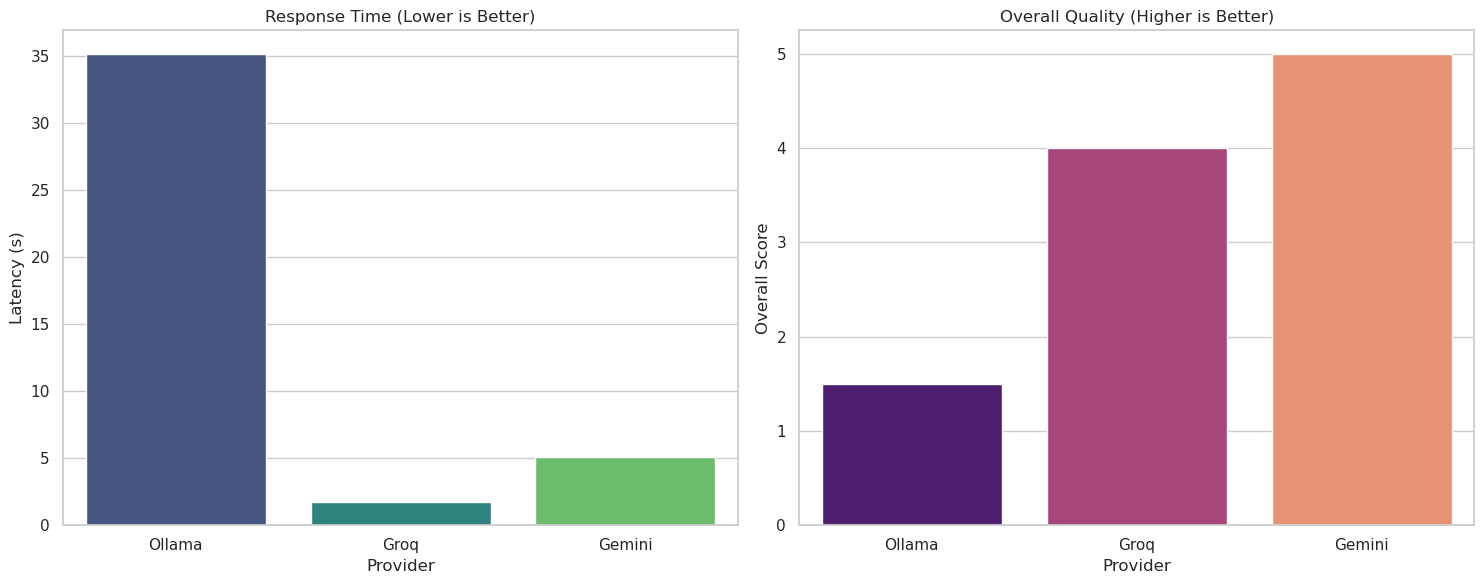

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Latency Plot
sns.barplot(x='Provider', y='Latency (s)', data=metrics_df, ax=ax1, palette='viridis')
ax1.set_title('Response Time (Lower is Better)')

# Quality Plot
sns.barplot(x='Provider', y='Overall Score', data=metrics_df, ax=ax2, palette='magma')
ax2.set_title('Overall Quality (Higher is Better)')

plt.tight_layout()
plt.show()

In [87]:
import warnings
warnings.filterwarnings('ignore')